# Step 1: Importing Required Libraries

In [15]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split

import nltk
import string
import warnings
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

import tensorflow as tf
from tensorflow import keras
from keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

nltk.download('stopwords')
nltk.download('omw-1.4')
nltk.download('wordnet')
warnings.filterwarnings('ignore')

# Step 2: Loading the Dataset

In [2]:
# Splits produced by ml/data/split.py (stratified 70/15/15).
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

# Alias for downstream cells that reference `df` (shape / info / pie).
df = train_df

print(f"train: {train_df.shape}  val: {val_df.shape}  test: {test_df.shape}")
df.head()


train: (17347, 2)  val: (3718, 2)  test: (3718, 2)


,class,tweet
0,1,LMFAOOOOOO GAY AS FUCK RT @PubesOnFleeK: &#128...
1,1,RT @OGTREEZ: Steve found out you can't call Ta...
2,2,@SBPart01 @melodybrooke11 fuzzy dice might be ...
3,1,@Midnight_Snacka now fuck that stfu shit how a...
4,2,Shut up birds it's bed time.


In [3]:
df.shape

(17347, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17347 entries, 0 to 17346
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   class   17347 non-null  int64
 1   tweet   17347 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.7 MB


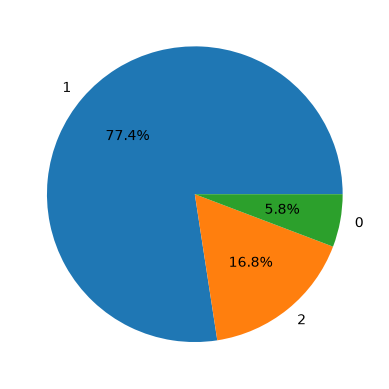

In [5]:
plt.pie(df['class'].value_counts().values,
        labels = df['class'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

# Step 3: Splits Already Prepared

`train_df` / `val_df` / `test_df` were produced by `ml/data/split.py` (stratified 70/15/15, pinned seed).
Class proportions match the raw distribution across all three splits, so no additional balancing is applied at this stage.


In [6]:
# Splits are pre-made (see cell 4); alias balanced_df to train_df so
# downstream cells that reference `balanced_df` (preprocessing,
# tokenization) keep working without changes.
balanced_df = train_df.copy()


# Step 4: Text Preprocessing

In [7]:
punctuations_list = string.punctuation


def remove_punctuations(text):
    temp = str.maketrans('', '', punctuations_list)
    return text.translate(temp)


for split_df in (train_df, val_df, test_df):
    split_df['tweet'] = split_df['tweet'].str.lower()
    split_df['tweet'] = split_df['tweet'].apply(lambda x: remove_punctuations(x))

train_df.head()


,class,tweet
0,1,lmfaoooooo gay as fuck rt pubesonfleek 1285571...
1,1,rt ogtreez steve found out you cant call taiqu...
2,2,sbpart01 melodybrooke11 fuzzy dice might be th...
3,1,midnightsnacka now fuck that stfu shit how a b...
4,2,shut up birds its bed time


In [8]:
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(words)


for split_df in (train_df, val_df, test_df):
    split_df['tweet'] = split_df['tweet'].apply(preprocess_text)


# Step 5: Tokenization and Padding

In [9]:
X_train = train_df['tweet']
Y_train = train_df['class']
X_val = val_df['tweet']
Y_val = val_df['class']

# One-hot encode the labels
Y_train = pd.get_dummies(Y_train)
Y_val = pd.get_dummies(Y_val)

# Tokenization
max_words = 5000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, lower=True, split=' ')
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

# Pad sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')


# Step 6: Build the Model

In [10]:
from tensorflow import keras
from tensorflow.keras import layers

max_words = 10000
max_len = 100 

model = keras.models.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=32, input_length=max_len),
    layers.Bidirectional(layers.LSTM(16)),
    layers.Dense(512, activation='relu', kernel_regularizer='l1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  
])

model.build(input_shape=(None, max_len))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 346,755 (1.32 MB)

 Trainable params: 345,731 (1.32 MB)

 Non-trainable params: 1,024 (4.00 KB)

# Step 7: Training the Model

In [11]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(patience=3, monitor='val_accuracy', restore_best_weights=True)
lr = ReduceLROnPlateau(patience=2, monitor='val_loss', factor=0.5, verbose=0)

In [12]:
history = model.fit(X_train_padded, Y_train,
                    validation_data=(X_val_padded, Y_val),
                    epochs=50,
                    batch_size=32,
                    callbacks=[es, lr])

Epoch 1/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8584 - loss: 1.0582 - val_accuracy: 0.7789 - val_loss: 0.6695 - learning_rate: 0.0010
Epoch 2/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9022 - loss: 0.3516 - val_accuracy: 0.8838 - val_loss: 0.3949 - learning_rate: 0.0010
Epoch 3/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9159 - loss: 0.2919 - val_accuracy: 0.8878 - val_loss: 0.3797 - learning_rate: 0.0010
Epoch 4/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9327 - loss: 0.2381 - val_accuracy: 0.8854 - val_loss: 0.4151 - learning_rate: 0.0010
Epoch 5/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9452 - loss: 0.2007 - val_accuracy: 0.8798 - val_loss: 0.4447 - learning_rate: 0.0010
Epoch 6/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9594 - loss: 0.1451 - val_accuracy: 0.8852 - val_loss: 0.4530 - learning_rate: 5.0000e-04


# Step 8: Evaluating the Model

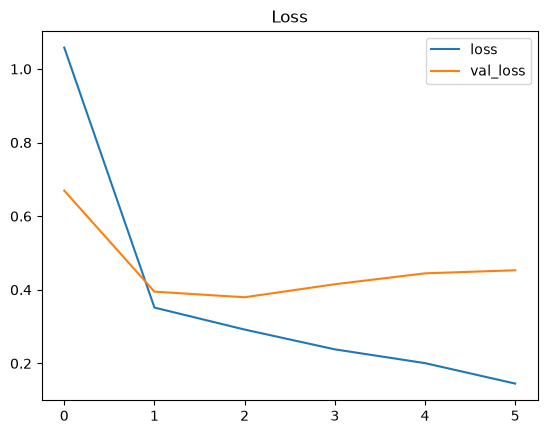

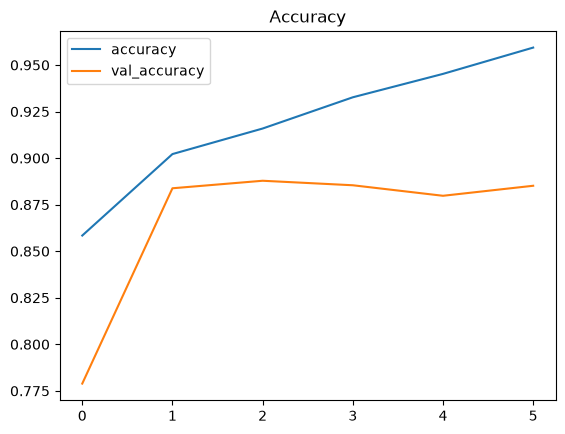

In [13]:
history_df = pd.DataFrame(history.history)

history_df[['loss', 'val_loss']].plot(title="Loss")

history_df[['accuracy', 'val_accuracy']].plot(title="Accuracy")
plt.show()

In [14]:
# Evaluate on the validation set
val_loss, val_acc = model.evaluate(X_val_padded, Y_val)
print(f"Validation Accuracy: {val_acc:.2f}")

# Evaluate on the held-out test set (never seen during training)
X_test_seq = tokenizer.texts_to_sequences(test_df['tweet'])
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')
Y_test = pd.get_dummies(test_df['class'])
test_loss, test_acc = model.evaluate(X_test_padded, Y_test)
print(f"Test Accuracy: {test_acc:.2f}")


117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8878 - loss: 0.3797
Validation Accuracy: 0.89
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8892 - loss: 0.3681
Test Accuracy: 0.89


# Step 9: Save Model Artifacts

Persist the trained BiLSTM model + tokenizer + a small metadata
sidecar to `models/bilstm/` so FastAPI (#14) and the SageMaker
inference container (#15) can load them without re-running training.

Three files written:
- `bilstm.keras` — Keras model (architecture + weights)
- `tokenizer.json` — Keras Tokenizer, `to_json()` includes the
  fitted `word_index` and config; reloadable in TF 2.x via
  `tokenizer_from_json`
- `meta.json` — `max_len`, `max_words`, label mapping, model version

All artifacts land under `models/` which is gitignored.


In [16]:
import json
from pathlib import Path

ARTIFACT_DIR = Path('../models/bilstm')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save the Keras model (architecture + weights).
model_path = ARTIFACT_DIR / 'bilstm.keras'
model.save(model_path)
print(f'Saved model:     {model_path}  ({model_path.stat().st_size / 1e6:.2f} MB)')

# 2. Save the Keras Tokenizer. `to_json()` includes both the config
# (num_words, lower, split, ...) and the fitted word_index; reloadable
# via `keras.preprocessing.text.tokenizer_from_json`.
tokenizer_path = ARTIFACT_DIR / 'tokenizer.json'
with tokenizer_path.open('w', encoding='utf-8') as f:
    f.write(tokenizer.to_json())
print(f'Saved tokenizer: {tokenizer_path}')

# 3. Save a small metadata sidecar so the inference module doesn't
# have to remember hyperparameters or the label mapping.
meta = {
    'max_len': max_len,
    'max_words': max_words,
    'label_names': ['hate_speech', 'offensive_language', 'neither'],
    'label_ids': [0, 1, 2],
    'model_version': 'bilstm-v1',
}
meta_path = ARTIFACT_DIR / 'meta.json'
with meta_path.open('w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)
print(f'Saved metadata:  {meta_path}')

print()
print(f'All artifacts written to {ARTIFACT_DIR.resolve()}')


Saved model:     ..\models\bilstm\bilstm.keras  (4.20 MB)
Saved tokenizer: ..\models\bilstm\tokenizer.json
Saved metadata:  ..\models\bilstm\meta.json

All artifacts written to C:\Users\Sumit Das\experiments\app-development\safepost-ai\models\bilstm
